# Silhouette pose fit: one bone at a time (Roc test harness)

Experiment harness for the original 30 Roc animation frames (not RIFE). Winning pose is kept after each bone; candidates are scored one bone at a time.

**Score (default):** soft **depth** IoU — monocular-**predicted** sprite depth vs rendered mesh Z (near=1). Alpha alone is occupancy, not depth. Optional chroma mode remains in the worker.

**Order / ranges:** unit-agnostic hierarchy inside→outside (`pose_fit_auto.py`); depth IoU scores the fit.


In [1]:
from pathlib import Path
import json, math, subprocess, time, os, sys
import numpy as np
from PIL import Image

ROOT = Path(r"V:/Games/Olden Era Playtest Tweak")
TOOL = ROOT / "tools/homm3_silhouette_pose_fit"
sys.path.insert(0, str(TOOL))
import importlib
import pose_fit_auto

importlib.reload(pose_fit_auto)
from pose_fit_auto import build_dependency_order, build_range_table, filter_search_bones

# --- This test's inputs (swap per unit; not solver logic) ---
PILOT = ROOT / "artifacts/roc_pose_pipeline/smart_rig_move_pilot"
SRC_GLB = Path(r"C:/Users/levir/Downloads/griffon_smart_rigged.glb")
ANIMATION_TARGET_FRAMES = PILOT / "frames_nn_shadow_culled"
TARGET_FRAMES = ANIMATION_TARGET_FRAMES
TARGET_DEPTH = PILOT / "frames_depth_predicted"  # monocular depth (near=bright)
CAMERA_FIT = PILOT / "roc_sprite_camera_fit.json"
WORKER = TOOL / "roc_chroma_match_worker.py"
BLENDER = Path(r"V:/Games/actionmesh/tools/blender-3.5.1/blender.exe")
WIDTH, HEIGHT = 768, 683
SCORE_MODE = "depth"          # "depth" | "chroma"
DEPTH_MAX_DIST = 0.99         # soft depth agreement falloff in [0,1]
COLOR_MAX_DIST = 0.30         # only used if SCORE_MODE == "chroma"
# Blue = pred-only spill. 1.0 = normal IoU; >1 penalizes mesh outside sprite more.
PRED_ONLY_PENALTY = 2.5
# Compound = simultaneous local Euler on SEARCH_AXES. Sparse joint proposals + CD refine.
# Blender bones aim along +Y (shaft). Skipping Y in SEARCH_AXES is not enough: X+Z still
# induces roll — worker strips twist about the bone shaft when EXCLUDE_BONE_ROLL is set.
# Alternatives: "cascade" / "probe_one" / "full" (single-axis only winners).
EXCLUDE_BONE_ROLL = True
ROLL_AXIS = "y"  # bone-length axis in Blender
SEARCH_AXES = ("x", "z") if EXCLUDE_BONE_ROLL else ("x", "y", "z")
MULTI_AXIS_MODE = "compound"
AXIS_PROBE_FIRST = True
COARSE_STEP_DEG = 16.0
REFINE_STEP_DEG = 4.0
CASCADE_SECONDARY_FRAC = 0.45
COMPOUND_PAIR_STEP_MULT = 1.0   # pair/triple grid uses coarse_step * this
COMPOUND_CD_ROUNDS = 2          # coordinate-descent refine rounds after joint proposals
SKIP_TINY_BONES = True
assert SRC_GLB.exists() and CAMERA_FIT.exists() and TARGET_FRAMES.exists()
print("targets:", len(list(TARGET_FRAMES.glob("*.png"))), "scoreMode:", SCORE_MODE,
      "multiAxis:", MULTI_AXIS_MODE)


targets: 30 scoreMode: depth multiAxis: compound


## 1. Targets + predicted sprite depth

Sprites only give a flat alpha mask. Depth for scoring is **predicted** with Depth Anything V2 Small (masked by alpha, near=bright), then compared to mesh Z from Blender.


In [2]:
from predict_sprite_depth import build_pipe, predict_sprite_depth, save_depth_u16

sources = sorted(ANIMATION_TARGET_FRAMES.glob("*.png"))
assert sources, f"no target frames in {TARGET_FRAMES}"
TARGET_DEPTH.mkdir(parents=True, exist_ok=True)

need = [p for p in sources if not (TARGET_DEPTH / p.name).is_file()]
if need:
    print(f"predicting depth for {len(need)}/{len(sources)} frames with Depth Anything V2 Small...")
    pipe = build_pipe()
    for i, src in enumerate(need, 1):
        rgba = np.asarray(Image.open(src).convert("RGBA"), dtype=np.uint8)
        depth = predict_sprite_depth(rgba, pipe)
        save_depth_u16(TARGET_DEPTH / src.name, depth)
        if i % 5 == 0 or i == len(need):
            print(f"  [{i}/{len(need)}] {src.name}")
else:
    print("predicted depth already present:", TARGET_DEPTH)

print("frames:", len(sources), "depth maps:", len(list(TARGET_DEPTH.glob("*.png"))))


predicted depth already present: V:\Games\Olden Era Playtest Tweak\artifacts\roc_pose_pipeline\smart_rig_move_pilot\frames_depth_predicted
frames: 30 depth maps: 30


## 2. Auto bone order and angle ranges

After worker `init`, unlocked bones are ordered **inside→outside by hierarchy** (more descendants first; leaves last). Camera near/far is not used. Hierarchy roots, **global hubs** (≥25% of skeleton), and **branching multi-limb hubs** stay locked unless you clear `locked`. Re-run the imports cell so `importlib.reload` picks up solver changes.


In [3]:
# Populated by the worker init cell.
order = []
RANGE_BY_BONE = {}
order_groups = {}

def range_for(name):
    return RANGE_BY_BONE.get(name, (-90.0, 90.0))

def bone_side(name):
    if name in order_groups.get("near", []):
        return "near"
    if name in order_groups.get("far", []):
        return "far"
    return "center"

print("run the worker init cell to populate order / ranges")


run the worker init cell to populate order / ranges


## 3. Persistent Blender worker

`init` / `score` / `set_pose` / `save_render`. Search is Workbench + Z pass. Default score is soft depth IoU. Init also returns `parents` and `boneHeads` for auto ordering.


In [4]:
class BlenderWorker:
    def __init__(self):
        self.proc = subprocess.Popen(
            [str(BLENDER), "-b", "--python", str(WORKER)],
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.DEVNULL,
            text=True,
            bufsize=1,
        )

    def request(self, command):
        self.proc.stdin.write(json.dumps(command) + "\n")
        self.proc.stdin.flush()
        while True:
            line = self.proc.stdout.readline()
            if not line:
                raise RuntimeError("Blender worker exited")
            try:
                return json.loads(line)
            except json.JSONDecodeError:
                continue

    def close(self):
        if self.proc.poll() is None:
            self.request({"cmd": "quit"})
            self.proc.wait(timeout=10)

worker = BlenderWorker()
init_result = worker.request(
    {
        "cmd": "init",
        "src": str(SRC_GLB),
        "fit": str(CAMERA_FIT),
        "width": WIDTH,
        "height": HEIGHT,
        "searchScale": 0.35,
        "searchEngine": "BLENDER_WORKBENCH",
        "searchTaaSamples": 1,
        "proofEngine": "BLENDER_EEVEE",
        "proofTaaSamples": 8,
        "scoreMode": SCORE_MODE,
        "depthMaxDist": DEPTH_MAX_DIST,
        "colorMaxDist": COLOR_MAX_DIST,
        "predOnlyPenalty": float(globals().get("PRED_ONLY_PENALTY", 2.5)),
        "targetEdgeSigmaPx": float(globals().get("TARGET_EDGE_SIGMA_PX", 4.0)),
        "targetEdgeFloor": float(globals().get("TARGET_EDGE_FLOOR", 0.25)),
        # Strip twist about bone shaft after each delta (X+Z Euler still induces roll).
        "stripBoneRoll": bool(globals().get("EXCLUDE_BONE_ROLL", True)),
    }
)
assert init_result["ok"], init_result

bones = init_result["bones"]
order, order_groups = build_dependency_order(
    bones,
    parents=init_result["parents"],
    heads=init_result["boneHeads"],
    view=init_result["view"],
    right=init_result["right"],
)
RANGE_BY_BONE = build_range_table(
    bones,
    parents=init_result["parents"],
    heads=init_result["boneHeads"],
    # locked=order_groups["locked"],
    locked=[],
    unrestricted=True,
    free_deg=90.0,
)

def range_for(name):
    return RANGE_BY_BONE.get(name, (-90.0, 90.0))

def bone_side(name):
    if name in order_groups.get("near", []):
        return "near"
    if name in order_groups.get("far", []):
        return "far"
    return "center"

print(
    "bones:", len(bones),
    "scoreMode:", init_result.get("scoreMode"),
    "locked:", order_groups["locked"],
    "hubCut:", order_groups.get("hubDescendantCut"),
    "orderMode:", order_groups.get("orderMode"),
    "inside-out:", order[:10],
    "leaves-last:", order[-6:],
    "search:", init_result["searchWidth"], "x", init_result["searchHeight"],
)
desc = order_groups.get("descendantCount") or {}
heavy = sorted(
    [b for b in order if abs(range_for(b)[1]) > 1e-6],
    key=lambda b: (-desc.get(b, 0), b),
)[:8]
print(
    "heaviest unlocked:",
    [(b, desc.get(b), range_for(b)) for b in heavy],
)


bones: 46 scoreMode: depth locked: ['Bone_000', 'Bone_001', 'Bone_002', 'Bone_003'] hubCut: 11 orderMode: inside_out_hierarchy inside-out: ['Bone_022', 'Bone_025', 'Bone_021', 'Bone_024', 'Bone_020', 'Bone_023', 'Bone_019', 'Bone_018', 'Bone_011', 'Bone_016'] leaves-last: ['Bone_030', 'Bone_032', 'Bone_035', 'Bone_038', 'Bone_040', 'Bone_043'] search: 269 x 239
heaviest unlocked: [('Bone_022', 10, (-90.0, 90.0)), ('Bone_025', 10, (-90.0, 90.0)), ('Bone_021', 9, (-90.0, 90.0)), ('Bone_024', 9, (-90.0, 90.0)), ('Bone_020', 8, (-90.0, 90.0)), ('Bone_023', 8, (-90.0, 90.0)), ('Bone_019', 6, (-90.0, 90.0)), ('Bone_018', 5, (-90.0, 90.0))]


## Local GPU anatomical boxes

Grounding DINO runs locally through Transformers on CUDA. It uses a fixed anatomical vocabulary for both the sprite target and mesh renders. Target boxes are passed into the inner score loop; the worker builds cheap current-pose boxes from the named bones so the detector is not rerun for every angle candidate. Full detector boxes are still produced for each committed mesh frame as a visual audit.


In [5]:
# LOCAL_GPU_ANATOMICAL_BOX_STAGE
from roc_anatomical_boxes import (RocAnatomicalBoxDetector, FIXED_PART_LIBRARY, draw_boxes, write_boxes)
PART_BOX_MODEL_ID = 'IDEA-Research/grounding-dino-tiny'
ANATOMICAL_PART_WEIGHT = 0.20
PART_BOX_OUT = PILOT / 'roc_anatomical_boxes'
PART_BOX_OUT.mkdir(parents=True, exist_ok=True)
SHOW_ANATOMICAL_BOXES = False  # hidden for semantic-only pilot
detector = RocAnatomicalBoxDetector(model_id=PART_BOX_MODEL_ID) if SHOW_ANATOMICAL_BOXES else None  # CUDA only
PART_BOXES_BY_FRAME = {}
def normalized_boxes(boxes, width, height):
    return [{'part': b.part, 'box': (b.box[0]/width, b.box[1]/height, b.box[2]/width, b.box[3]/height), 'score': b.score} for b in boxes]
def detect_target_boxes(frame_index):
    source = ANIMATION_TARGET_FRAMES / f'{frame_index:02d}.png'
    boxes = detector.detect(Image.open(source))
    PART_BOXES_BY_FRAME[frame_index] = normalized_boxes(boxes, WIDTH, HEIGHT)
    draw_boxes(Image.open(source), boxes, PART_BOX_OUT / f'sprite_{frame_index:02d}_boxes.png', f'sprite frame {frame_index:02d} local CUDA boxes')
    write_boxes(PART_BOX_OUT / f'sprite_{frame_index:02d}_boxes.json', boxes, image=source, device='cuda:0', model_id=PART_BOX_MODEL_ID)
if SHOW_ANATOMICAL_BOXES:
    for frame_index in range(30):
        detect_target_boxes(frame_index)
    print('detected target box frames:', len(PART_BOXES_BY_FRAME), 'library:', FIXED_PART_LIBRARY)
else:
    print('anatomical box detector disabled for semantic-only pilot')


anatomical box detector disabled for semantic-only pilot


## 4. Multi-axis single-bone search

Coarse-to-fine over local X/Y/Z; keep best axis+angle. Live preview: **predicted sprite depth | mesh depth | soft IoU**.


c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 44438.25it/s]
[transformers] CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n

SEARCH_AXES ('x', 'z') (roll excluded)
search bones: 40/42 (skip_tiny=True, axes=('x', 'z'), coarse=16.0, refine=4.0)


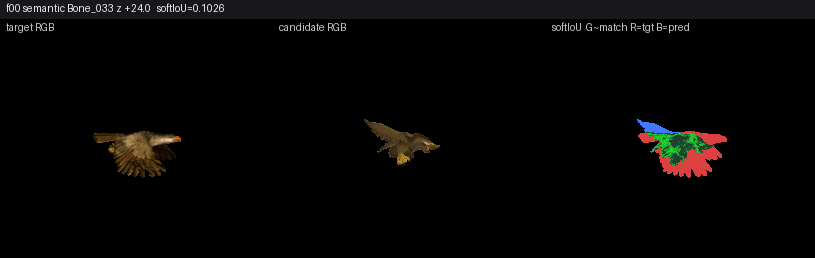

f00 Bone_022: semantic=0.9198 evals=18 elapsed=1.36s
f00 Bone_025: semantic=0.9296 evals=18 elapsed=1.19s
f00 Bone_021: semantic=0.9423 evals=18 elapsed=1.22s
f00 Bone_024: semantic=0.9423 evals=18 elapsed=1.11s
f00 Bone_020: semantic=0.9423 evals=18 elapsed=1.13s
f00 Bone_023: semantic=0.9423 evals=18 elapsed=1.19s
f00 Bone_019: semantic=0.9423 evals=18 elapsed=1.12s
f00 Bone_018: semantic=0.9423 evals=18 elapsed=1.12s
f00 Bone_011: semantic=0.9496 evals=18 elapsed=1.12s
f00 Bone_016: semantic=0.9557 evals=18 elapsed=1.17s
f00 Bone_017: semantic=0.9557 evals=18 elapsed=1.14s
f00 Bone_010: semantic=0.9581 evals=18 elapsed=1.18s
f00 Bone_015: semantic=0.9581 evals=18 elapsed=1.12s
f00 Bone_006: semantic=0.9581 evals=18 elapsed=1.12s
f00 Bone_009: semantic=0.9581 evals=18 elapsed=1.13s
f00 Bone_014: semantic=0.9581 evals=18 elapsed=1.17s
f00 Bone_034: semantic=0.9581 evals=18 elapsed=1.11s
f00 Bone_037: semantic=0.9581 evals=18 elapsed=1.15s
f00 Bone_042: semantic=0.9581 evals=18 elapsed

KeyboardInterrupt: 

In [6]:
from tqdm import tqdm
import time
from IPython.display import display, update_display, Image as IPImage

# Live watch: each score writes target | render | IoU and refreshes this output.
LIVE_PREVIEW = True
PREVIEW_EVERY = 1  # set to 2/3/... to refresh less often (faster)
PREVIEW_PATH = PILOT / "tmp" / "live_chroma_preview.png"
PREVIEW_PATH.parent.mkdir(parents=True, exist_ok=True)
_LIVE_DISPLAY_ID = 'roc_pose_live_preview'
_LIVE_DISPLAY_STARTED = False
def update_live_preview_image():
    global _LIVE_DISPLAY_STARTED
    if not PREVIEW_PATH.exists():
        return
    image = IPImage(filename=str(PREVIEW_PATH))
    if _LIVE_DISPLAY_STARTED:
        update_display(image, display_id=_LIVE_DISPLAY_ID)
    else:
        display(image, display_id=_LIVE_DISPLAY_ID)
        _LIVE_DISPLAY_STARTED = True
_preview_state = {"n": 0, "best_iou": -1.0, "best_label": ""}
# Slow first-frame semantic pilot toggle. True replaces depth/silhouette as the decision score.
SEMANTIC_ONLY = True
SEMANTIC_MODEL_ID = 'google/siglip2-base-patch16-512'
if SEMANTIC_ONLY:
    from roc_semantic_embedding_match import RocSemanticEmbedder
    semantic_encoder = RocSemanticEmbedder(model_id=SEMANTIC_MODEL_ID)  # asserts CUDA
    _semantic_target_vectors = {}
    _semantic_candidate_dir = PILOT / 'tmp' / 'semantic_candidates'
    _semantic_candidate_dir.mkdir(parents=True, exist_ok=True)
    def semantic_target_vector(frame_index):
        if frame_index not in _semantic_target_vectors:
            image = semantic_encoder.load_image(ANIMATION_TARGET_FRAMES / f'{frame_index:02d}.png')
            _semantic_target_vectors[frame_index] = semantic_encoder.embed([image])[0]
        return _semantic_target_vectors[frame_index]

# Local bind axes / multi-axis policy from imports cell.
EXCLUDE_BONE_ROLL = bool(globals().get("EXCLUDE_BONE_ROLL", True))
ROLL_AXIS = str(globals().get("ROLL_AXIS", "y")).lower()
_default_axes = ("x", "z") if EXCLUDE_BONE_ROLL else ("x", "y", "z")
SEARCH_AXES = tuple(
    a for a in globals().get("SEARCH_AXES", _default_axes)
    if (not EXCLUDE_BONE_ROLL) or (str(a).lower() != ROLL_AXIS)
)
if not SEARCH_AXES:
    SEARCH_AXES = _default_axes
MULTI_AXIS_MODE = str(globals().get("MULTI_AXIS_MODE", "compound"))
AXIS_PROBE_FIRST = bool(globals().get("AXIS_PROBE_FIRST", True))
COARSE_STEP_DEG = float(globals().get("COARSE_STEP_DEG", 16.0))
REFINE_STEP_DEG = float(globals().get("REFINE_STEP_DEG", 4.0))
CASCADE_SECONDARY_FRAC = float(globals().get("CASCADE_SECONDARY_FRAC", 0.45))
COMPOUND_PAIR_STEP_MULT = float(globals().get("COMPOUND_PAIR_STEP_MULT", 1.0))
COMPOUND_CD_ROUNDS = int(globals().get("COMPOUND_CD_ROUNDS", 2))
SKIP_TINY_BONES = bool(globals().get("SKIP_TINY_BONES", True))
print("SEARCH_AXES", SEARCH_AXES, "(roll excluded)" if EXCLUDE_BONE_ROLL else "(roll included)")

def show_live_preview(label, iou):
    """Refresh the 3-panel preview. Uses raw PNG bytes to avoid PIL vs IPython Image clashes."""
    if not LIVE_PREVIEW:
        return
    _preview_state["n"] += 1
    if iou >= _preview_state["best_iou"]:
        _preview_state["best_iou"] = float(iou)
        _preview_state["best_label"] = label
    if PREVIEW_EVERY > 1 and (_preview_state["n"] % PREVIEW_EVERY) != 0:
        return
    if not PREVIEW_PATH.exists():
        return
    print(
        f"{label}   IoU={iou:.4f}   best={_preview_state['best_iou']:.4f} "
        f"({_preview_state['best_label']})   trial #{_preview_state['n']}"
    )
    print("panels: tgtDepth(pred) | predDepth | IoU  (green~match, red=target only, blue=pred only)")
    update_live_preview_image()

def scan_bone_axis(
    frame_index,
    bone,
    accumulated,
    axis,
    coarse_step=None,
    refine_step=None,
    progress_desc=None,
    live_preview=None,
):
    """Coarse-to-fine sweep on one local axis. Returns (angle_rad, iou, trials, timings)."""
    live = LIVE_PREVIEW if live_preview is None else live_preview
    coarse_step = float(COARSE_STEP_DEG if coarse_step is None else coarse_step)
    refine_step = float(REFINE_STEP_DEG if refine_step is None else refine_step)
    lo, hi = range_for(bone)
    target = ANIMATION_TARGET_FRAMES / f"{frame_index:02d}.png"
    target_depth = TARGET_DEPTH / f"{frame_index:02d}.png"
    trials = []
    timings = {
        "axis": axis,
        "coarse_total": 0.0,
        "coarse_all_evals": [],
        "coarse_maxangle": None,
        "refine_total": 0.0,
        "refine_all_evals": [],
        "angle_evaluations": [],
    }
    _preview_state["best_iou"] = -1.0
    _preview_state["best_label"] = ""

    def evaluate(angle_deg, region):
        pose = dict(accumulated)
        pose[bone] = {"axis": axis, "angle": math.radians(angle_deg)}
        t0 = time.perf_counter()
        caption = (
            f"f{frame_index:02d} {progress_desc or bone}  "
            f"{axis.upper()} {region}  {angle_deg:.1f}deg"
        )
        req = {
            "cmd": "score",
            "target": str(target),
            "targetDepth": str(target_depth),
            "angles": pose,
            "scoreMode": SCORE_MODE,
            "depthMaxDist": DEPTH_MAX_DIST,
            "colorMaxDist": COLOR_MAX_DIST,
            "targetPartBoxes": PART_BOXES_BY_FRAME.get(frame_index, []),
            "anatomicalPartWeight": ANATOMICAL_PART_WEIGHT,
            "showAnatomicalBoxes": SHOW_ANATOMICAL_BOXES,
        }
        if live:
            req["previewOut"] = str(PREVIEW_PATH)
            req["previewRgb"] = True
            req["previewCaption"] = caption
        if SEMANTIC_ONLY:
            req['scoreMode'] = 'chroma'
            req['previewRgb'] = True
            req['semanticCandidateOut'] = str(_semantic_candidate_dir / f'f{frame_index:02d}_{bone}_{axis}_{region}_{angle_deg:+07.2f}.png')
        result = worker.request(req)
        if not result.get('ok'):
            raise RuntimeError(result)
        if SEMANTIC_ONLY:
            candidate_image = semantic_encoder.load_image(Path(req['semanticCandidateOut']))
            candidate_vector = semantic_encoder.embed([candidate_image])[0]
            semantic_score = float(np.dot(semantic_target_vector(frame_index), candidate_vector))
            result['silhouetteIoU'] = float(result.get('iou', 0.0))
            result['semanticCosine'] = semantic_score
            result['iou'] = semantic_score
        dt = time.perf_counter() - t0
        if not result.get("ok"):
            raise RuntimeError(result)
        iou = float(result["iou"])
        if live:
            show_live_preview(caption, iou)
        eval_info = {
            "axis": axis,
            "angle": float(angle_deg),
            "iou": iou,
            "region": region,
            "dt_score": dt,
        }
        timings["angle_evaluations"].append(eval_info)
        if region == "coarse":
            timings["coarse_all_evals"].append(eval_info)
        else:
            timings["refine_all_evals"].append(eval_info)
        trials.append((axis, float(angle_deg), iou))
        return iou

    if lo == hi:
        # Locked bone: score bind (0) once.
        score = evaluate(float(lo), "coarse")
        timings["coarse_total"] = 0.0
        timings["coarse_maxangle"] = float(lo)
        return math.radians(float(lo)), float(score), trials, timings

    coarse_step_eff = float(coarse_step)
    span = float(hi) - float(lo)
    if span > 1e-9:
        # Keep several samples inside tight hub/limb caps (e.g. ±6° with default step 8).
        coarse_step_eff = min(coarse_step_eff, max(float(refine_step), span / 4.0))
    coarse = np.arange(lo, hi + coarse_step_eff * 0.5, coarse_step_eff)
    if lo <= 0.0 <= hi and not np.any(np.isclose(coarse, 0.0)):
        coarse = np.unique(np.append(coarse.astype(float), 0.0))
    t0 = time.perf_counter()
    coarse_results = []
    coarse_iter = coarse if live else tqdm(coarse, desc=f"{progress_desc} {axis} coarse", leave=False)
    for a in coarse_iter:
        coarse_results.append((float(a), evaluate(float(a), "coarse")))
    timings["coarse_total"] = time.perf_counter() - t0
    best_angle, best_score = max(coarse_results, key=lambda x: x[1])
    timings["coarse_maxangle"] = best_angle

    fine = np.arange(
        max(lo, best_angle - coarse_step),
        min(hi, best_angle + coarse_step) + refine_step * 0.5,
        refine_step,
    )
    t0 = time.perf_counter()
    fine_iter = fine if live else tqdm(fine, desc=f"{progress_desc} {axis} refine", leave=False)
    for angle in fine_iter:
        score = evaluate(float(angle), "refine")
        if score > best_score:
            best_angle, best_score = float(angle), score
    timings["refine_total"] = time.perf_counter() - t0

    return math.radians(best_angle), float(best_score), trials, timings

def scan_bone(frame_index, bone, accumulated, coarse_step=None, refine_step=None, progress_desc=None, live_preview=None, axes=None):
    """Search bone rotation. Default compound = simultaneous local Euler x+y+z."""
    live = LIVE_PREVIEW if live_preview is None else live_preview
    coarse_step = float(COARSE_STEP_DEG if coarse_step is None else coarse_step)
    refine_step = float(REFINE_STEP_DEG if refine_step is None else refine_step)
    axes = [a.lower() for a in (axes or SEARCH_AXES)]
    mode = str(MULTI_AXIS_MODE).lower()
    lo, hi = range_for(bone)
    target = ANIMATION_TARGET_FRAMES / f"{frame_index:02d}.png"
    target_depth = TARGET_DEPTH / f"{frame_index:02d}.png"
    all_trials = []
    timings = {"mode": mode, "angle_evaluations": [], "axesTried": list(axes)}

    def _clip(deg):
        return float(min(hi, max(lo, deg)))

    def _score_euler_deg(euler_deg, region):
        pose = dict(accumulated)
        pose[bone] = {
            "x": math.radians(float(euler_deg.get("x", 0.0))),
            "y": math.radians(float(euler_deg.get("y", 0.0))),
            "z": math.radians(float(euler_deg.get("z", 0.0))),
        }
        caption = (
            f"f{frame_index:02d} {progress_desc or bone}  "
            f"XYZ {region}  "
            f"({euler_deg.get('x', 0):.0f},{euler_deg.get('y', 0):.0f},{euler_deg.get('z', 0):.0f})"
        )
        req = {
            "cmd": "score",
            "target": str(target),
            "targetDepth": str(target_depth),
            "angles": pose,
            "scoreMode": SCORE_MODE,
            "depthMaxDist": DEPTH_MAX_DIST,
            "colorMaxDist": COLOR_MAX_DIST,
            "targetPartBoxes": PART_BOXES_BY_FRAME.get(frame_index, []),
            "anatomicalPartWeight": ANATOMICAL_PART_WEIGHT,
            "threshold": 0.08,
        }
        if live:
            req["previewOut"] = str(PREVIEW_PATH)
            req["previewRgb"] = True
            req["previewCaption"] = caption
        t0 = time.perf_counter()
        result = worker.request(req)
        dt = time.perf_counter() - t0
        if not result.get("ok"):
            raise RuntimeError(result)
        iou = float(result["iou"])
        if live:
            show_live_preview(caption, iou)
        all_trials.append(("xyz", dict(euler_deg), iou))
        timings["angle_evaluations"].append(
            {"eulerDeg": dict(euler_deg), "iou": iou, "region": region, "dt_score": dt}
        )
        return iou

    def _mags(step):
        vals = [0.0]
        m = float(step)
        lim = max(abs(lo), abs(hi))
        while m <= lim + 1e-9:
            if m <= hi + 1e-9:
                vals.append(m)
            if -m >= lo - 1e-9:
                vals.append(-m)
            m += float(step)
        return sorted(set(_clip(v) for v in vals))

    def _run_single_axis_modes():
        """Legacy: independent axis sweeps; return single-axis pose dict."""
        run_axes = list(axes)
        axis_timings = []
        local_trials = []

        def _run_axis(axis, *, step_coarse, step_refine):
            angle_rad, score, trials, t = scan_bone_axis(
                frame_index,
                bone,
                accumulated,
                axis,
                coarse_step=step_coarse,
                refine_step=step_refine,
                progress_desc=progress_desc,
                live_preview=live,
            )
            local_trials.extend(trials)
            axis_timings.append(t)
            return score, axis, angle_rad, trials, t

        if mode == "probe_one" and AXIS_PROBE_FIRST and len(run_axes) > 1:
            probe = float(min(coarse_step, max(abs(lo), abs(hi), 1.0)))
            probe_angles = [0.0]
            if lo < -1e-6:
                probe_angles.append(_clip(-probe))
            if hi > 1e-6:
                probe_angles.append(_clip(probe))
            best_probe = None
            for axis in run_axes:
                for a in probe_angles:
                    pose = dict(accumulated)
                    pose[bone] = {"axis": axis, "angle": math.radians(float(a))}
                    result = worker.request(
                        {
                            "cmd": "score",
                            "target": str(target),
                            "targetDepth": str(target_depth),
                            "angles": pose,
                            "scoreMode": SCORE_MODE,
                            "depthMaxDist": DEPTH_MAX_DIST,
                            "colorMaxDist": COLOR_MAX_DIST,
            "targetPartBoxes": PART_BOXES_BY_FRAME.get(frame_index, []),
            "anatomicalPartWeight": ANATOMICAL_PART_WEIGHT,
                            "threshold": 0.08,
                        }
                    )
                    if not result.get("ok"):
                        raise RuntimeError(result)
                    score = float(result["iou"])
                    local_trials.append((axis, float(a), score))
                    cand = (score, axis)
                    if best_probe is None or cand[0] > best_probe[0]:
                        best_probe = cand
            run_axes = [best_probe[1]]

        best = None
        for axis in run_axes:
            cand = _run_axis(axis, step_coarse=coarse_step, step_refine=refine_step)
            if best is None or cand[0] > best[0]:
                best = cand
        score, axis, angle_rad, _tr, t = best
        timings.update(
            {
                "chosenAxis": axis,
                "perAxis": axis_timings,
                "axesTried": list(run_axes),
            }
        )
        all_trials.extend(local_trials)
        return {"axis": axis, "angle": float(angle_rad)}, float(score), all_trials, timings

    if mode != "compound":
        return _run_single_axis_modes()

    # --- Simultaneous compound Euler (x+y+z) ---
    best_euler = {"x": 0.0, "y": 0.0, "z": 0.0}
    best_score = _score_euler_deg(best_euler, "bind")

    candidates = [best_euler.copy()]
    # 1D stars
    for ax in axes:
        for m in _mags(coarse_step):
            if abs(m) < 1e-9:
                continue
            e = {"x": 0.0, "y": 0.0, "z": 0.0}
            e[ax] = m
            candidates.append(e)
    # 2D simultaneous pairs (coarser / shorter mag list)
    pair_step = max(refine_step, coarse_step * float(COMPOUND_PAIR_STEP_MULT))
    mags2 = [m for m in _mags(pair_step) if abs(m) <= 2.0 * pair_step + 1e-9]
    for i, a1 in enumerate(axes):
        for a2 in axes[i + 1 :]:
            for m1 in mags2:
                for m2 in mags2:
                    if abs(m1) < 1e-9 and abs(m2) < 1e-9:
                        continue
                    e = {"x": 0.0, "y": 0.0, "z": 0.0}
                    e[a1], e[a2] = m1, m2
                    candidates.append(e)
    # 3D simultaneous sign patterns at 1× and 2× pair_step
    for s in (pair_step, 2.0 * pair_step):
        if s > max(abs(lo), abs(hi)) + 1e-9:
            continue
        for sx in (-1, 0, 1):
            for sy in (-1, 0, 1):
                for sz in (-1, 0, 1):
                    if sx == sy == sz == 0:
                        continue
                    e = {
                        "x": _clip(sx * s) if "x" in axes else 0.0,
                        "y": _clip(sy * s) if "y" in axes else 0.0,
                        "z": _clip(sz * s) if "z" in axes else 0.0,
                    }
                    candidates.append(e)

    # Dedupe
    uniq = {}
    for e in candidates:
        key = (
            round(float(e.get("x", 0.0)), 4),
            round(float(e.get("y", 0.0)), 4),
            round(float(e.get("z", 0.0)), 4),
        )
        uniq[key] = {
            "x": float(e.get("x", 0.0)),
            "y": float(e.get("y", 0.0)),
            "z": float(e.get("z", 0.0)),
        }
    candidates = list(uniq.values())
    timings["compoundCandidates"] = len(candidates)

    for e in candidates:
        if e["x"] == 0.0 and e["y"] == 0.0 and e["z"] == 0.0:
            continue
        score = _score_euler_deg(e, "joint")
        if score > best_score:
            best_score, best_euler = score, dict(e)

    # Coordinate-descent refine: move one axis at a time, keep others fixed (stays simultaneous).
    for _round in range(max(1, int(COMPOUND_CD_ROUNDS))):
        for ax in axes:
            center = float(best_euler.get(ax, 0.0))
            window = max(2.0 * refine_step, coarse_step)
            samples = np.arange(
                _clip(center - window),
                _clip(center + window) + refine_step * 0.5,
                refine_step,
            )
            if not np.any(np.isclose(samples, center)):
                samples = np.unique(np.append(samples.astype(float), center))
            for a in samples:
                trial = dict(best_euler)
                trial[ax] = float(a)
                score = _score_euler_deg(trial, f"cd{_round}_{ax}")
                if score > best_score:
                    best_score, best_euler = score, dict(trial)

    delta = {
        "x": math.radians(float(best_euler.get("x", 0.0))),
        "y": math.radians(float(best_euler.get("y", 0.0))),
        "z": math.radians(float(best_euler.get("z", 0.0))),
    }
    timings["chosenEulerDeg"] = dict(best_euler)
    timings["chosenAxis"] = "xyz"
    return delta, float(best_score), all_trials, timings

SEMANTIC_OPTIMIZER = True
SEMANTIC_INITIAL_STEP_DEG = 24.0
SEMANTIC_MIN_STEP_DEG = 2.0
SEMANTIC_MAX_EVALS_PER_AXIS = 9
SEMANTIC_MIN_IMPROVEMENT = 0.002

def optimize_frame_semantic(frame_index, initial=None, bones=None, progress=None, live_preview=None):
    """Adaptive coordinate descent using CLIP cosine similarity.

    Each bone/axis probes the current angle and both signed directions. It
    keeps a winning move, expands no further than the anatomical range, and
    halves the step when neither direction improves. This replaces the
    exhaustive coarse/refine grid for the semantic pilot only.
    """
    if not SEMANTIC_ONLY:
        raise RuntimeError("semantic optimizer requires SEMANTIC_ONLY=True")
    live = LIVE_PREVIEW if live_preview is None else live_preview
    target = ANIMATION_TARGET_FRAMES / f"{frame_index:02d}.png"
    target_depth = TARGET_DEPTH / f"{frame_index:02d}.png"
    pose = dict(initial or {})
    history, timings = [], []
    total_start = time.perf_counter()
    target_vec = semantic_target_vector(frame_index)
    eval_count = 0

    def score_pose(candidate, label):
        nonlocal eval_count
        eval_count += 1
        out = _semantic_candidate_dir / f"opt_f{frame_index:02d}_{eval_count:04d}.png"
        req = {
            "cmd": "score", "target": str(target),
            "targetDepth": str(target_depth), "angles": candidate,
            "scoreMode": "chroma", "previewRgb": bool(live),
            "semanticCandidateOut": str(out),
            "targetPartBoxes": PART_BOXES_BY_FRAME.get(frame_index, []),
            "anatomicalPartWeight": ANATOMICAL_PART_WEIGHT,
            "showAnatomicalBoxes": SHOW_ANATOMICAL_BOXES,
        }
        if live:
            req["previewOut"] = str(PREVIEW_PATH)
            req["previewCaption"] = f"f{frame_index:02d} semantic {label}"
        t0 = time.perf_counter()
        result = worker.request(req)
        if not result.get("ok"):
            raise RuntimeError(result)
        candidate_vec = semantic_encoder.embed([semantic_encoder.load_image(out)])[0]
        similarity = float(np.dot(target_vec, candidate_vec))
        if live:
            update_live_preview_image()
        timings.append({"label": label, "seconds": time.perf_counter() - t0, "score": similarity})
        return similarity

    for bone in (bones or pilot_bones):
        bone_start = time.perf_counter()
        bone_record = {"bone": bone, "axes": {}, "evaluations": 0}
        base = pose.get(bone, {})
        if base.get("axis"):
            euler = {"x": 0.0, "y": 0.0, "z": 0.0}
            euler[base["axis"]] = math.degrees(float(base.get("angle", 0.0)))
        else:
            euler = {a: math.degrees(float(base.get(a, 0.0))) for a in ("x", "y", "z")}
        for axis in SEARCH_AXES:
            lo, hi = range_for(bone)
            current = float(euler.get(axis, 0.0))
            current = min(max(current, lo), hi)
            candidate_entry = dict(euler); candidate_entry[axis] = current
            best = score_pose({**pose, bone: candidate_entry}, f"{bone} {axis} center")
            step = min(SEMANTIC_INITIAL_STEP_DEG, max(SEMANTIC_MIN_STEP_DEG, hi - lo))
            axis_evals = 1
            while step >= SEMANTIC_MIN_STEP_DEG and axis_evals + 2 <= SEMANTIC_MAX_EVALS_PER_AXIS:
                candidates = [min(hi, current + step), max(lo, current - step)]
                scored = [(score_pose({**pose, bone: {**euler, axis: a}}, f"{bone} {axis} {a:+.1f}"), a) for a in candidates if abs(a - current) > 1e-6]
                axis_evals += len(scored)
                if scored:
                    trial_score, trial_angle = max(scored, key=lambda item: item[0])
                else:
                    trial_score, trial_angle = best, current
                if trial_score > best + SEMANTIC_MIN_IMPROVEMENT:
                    best, current = trial_score, trial_angle
                    euler[axis] = current
                    pose[bone] = dict(euler)
                else:
                    step *= 0.5
            bone_record["axes"][axis] = {"angleDeg": current, "score": best, "evaluations": axis_evals}
            bone_record["evaluations"] += axis_evals
        bone_record["elapsed"] = time.perf_counter() - bone_start
        history.append(bone_record)
        print(f"f{frame_index:02d} {bone}: semantic={max(v['score'] for v in bone_record['axes'].values()):.4f} evals={bone_record['evaluations']} elapsed={bone_record['elapsed']:.2f}s")
    return pose, history, time.perf_counter() - total_start, timings

def optimize_frame(frame_index, initial=None, bones=None, progress=None, live_preview=None):
    live = LIVE_PREVIEW if live_preview is None else live_preview
    pose, history = dict(initial or {}), []
    overall_start = time.perf_counter()
    current_bones = bones or order
    if progress is None or live:
        it = enumerate(current_bones)
    else:
        it = tqdm(enumerate(current_bones), desc=f"Frame {frame_index}", total=len(current_bones))
    frame_timings = []
    for i, bone in it:
        progress_desc = f"Bone [{bone}]"
        bone_start = time.perf_counter()
        delta, score, trials, timings = scan_bone(
            frame_index, bone, pose, progress_desc=progress_desc, live_preview=live
        )
        bone_elapsed = time.perf_counter() - bone_start
        pose[bone] = delta
        if isinstance(delta, dict) and "axis" in delta:
            hist_axis = delta["axis"]
            hist_deg = math.degrees(delta["angle"])
            hist_label = f"{hist_axis.upper()} {hist_deg:.1f} deg"
        else:
            hist_axis = "xyz"
            hist_deg = {
                k: round(math.degrees(float(delta.get(k, 0.0))), 2)
                for k in ("x", "y", "z")
            }
            hist_label = (
                f"XYZ ({hist_deg['x']:.1f},{hist_deg['y']:.1f},{hist_deg['z']:.1f}) deg"
            )
        history.append({
            "bone": bone,
            "axis": hist_axis,
            "angleDeg": hist_deg,
            "iou": score,
            "trials": len(trials),
            "timings": timings,
            "elapsed": bone_elapsed,
        })
        frame_timings.append({"bone": bone, **timings, "elapsed_total": bone_elapsed})
        line = (
            f"f{frame_index:02d} {bone}: {hist_label} IoU={score:.4f} "
            f"(bone elapsed {bone_elapsed:.2f}s, mode={timings.get('mode')})"
        )
        if live:
            if PREVIEW_PATH.exists():
                update_live_preview_image()
            print(line)
        else:
            print(line)

    total_time = time.perf_counter() - overall_start
    print(f"Frame {frame_index}: total elapsed {total_time:.2f}s")
    return pose, history, total_time, frame_timings

# Pilot only: expand to `order` after reviewing timing and deformation.
# Set LIVE_PREVIEW=False above for headless speed.
pilot_bones = filter_search_bones(
    order,
    descendant_count=order_groups.get("descendantCount") or {},
    bone_length=order_groups.get("boneLength") or {},
    skip_tiny=SKIP_TINY_BONES,
)
print(
    f"search bones: {len(pilot_bones)}/{len(order)} "
    f"(skip_tiny={SKIP_TINY_BONES}, axes={SEARCH_AXES}, "
    f"coarse={COARSE_STEP_DEG}, refine={REFINE_STEP_DEG})"
)

# TEMPORARY: frame-0 pilot uses gen-upscaled sprite + its depth (revert by deleting this block).
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
# Original-frame-only contract: generated/temp targets are disabled.
_USE_UPSCALED_GEN_PILOT = False
# 1.0 = match original frame-00 silhouette size on the same canvas (mesh camera).
# Raise/lower if the bird still looks too small/large vs the mesh in the preview.
_UPSCALE_MESH_SCALE = 4.0
_ORIG_TARGET_FRAMES = TARGET_FRAMES
_ORIG_TARGET_DEPTH = TARGET_DEPTH
if _USE_UPSCALED_GEN_PILOT:
    from predict_sprite_depth import build_pipe, predict_sprite_depth, save_depth_u16

    def _alpha_bbox(rgba, thr=20):
        ys, xs = np.where(rgba[:, :, 3] > thr)
        if len(xs) == 0:
            raise RuntimeError("empty alpha")
        return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1

    TARGET_FRAMES = PILOT / "frames_upscaled_gen_pilot"
    TARGET_DEPTH = PILOT / "frames_upscaled_gen_depth"
    TARGET_FRAMES.mkdir(parents=True, exist_ok=True)
    TARGET_DEPTH.mkdir(parents=True, exist_ok=True)
    _dst_frame_00 = TARGET_FRAMES / "00.png"
    _dst_depth_00 = TARGET_DEPTH / "00.png"

    _ref = np.asarray(
        Image.open(_ORIG_TARGET_FRAMES / "00.png").convert("RGBA"), dtype=np.uint8
    )
    _src_path = PILOT / "tmp" / "depth_compare_00" / "upscaled_gen_rgba.png"
    if not _src_path.is_file():
        _src_path = PILOT / "frames_upscaled_gen" / "00.png"
    _up = np.asarray(Image.open(_src_path).convert("RGBA"), dtype=np.uint8)

    rx0, ry0, rx1, ry1 = _alpha_bbox(_ref)
    ux0, uy0, ux1, uy1 = _alpha_bbox(_up)
    ref_w, ref_h = rx1 - rx0, ry1 - ry0
    crop = _up[uy0:uy1, ux0:ux1]
    target_w = max(1, int(round(ref_w * float(_UPSCALE_MESH_SCALE))))
    target_h = max(1, int(round(ref_h * float(_UPSCALE_MESH_SCALE))))
    fitted = np.asarray(
        Image.fromarray(crop).resize((target_w, target_h), Image.Resampling.LANCZOS),
        dtype=np.uint8,
    )

    canvas = np.zeros_like(_ref)
    ref_cx = 0.5 * (rx0 + rx1)
    ref_cy = 0.5 * (ry0 + ry1)
    x0 = int(round(ref_cx - 0.5 * target_w))
    y0 = int(round(ref_cy - 0.5 * target_h))
    x1, y1 = x0 + target_w, y0 + target_h
    sx0, sy0 = max(0, -x0), max(0, -y0)
    dx0, dy0 = max(0, x0), max(0, y0)
    dx1, dy1 = min(canvas.shape[1], x1), min(canvas.shape[0], y1)
    sw, sh = dx1 - dx0, dy1 - dy0
    canvas[dy0:dy1, dx0:dx1] = fitted[sy0 : sy0 + sh, sx0 : sx0 + sw]
    Image.fromarray(canvas).save(_dst_frame_00)

    _pipe = build_pipe()
    save_depth_u16(_dst_depth_00, predict_sprite_depth(canvas, _pipe))
    # Bust any in-memory target cache in the persistent Blender worker.
    try:
        worker.request({"cmd": "clear_target_cache"})
    except Exception:
        pass
    print(
        "TEMP pilot target fitted to mesh canvas:",
        _ref.shape[1], "x", _ref.shape[0],
        "silhouette", target_w, "x", target_h,
        f"px={int((canvas[:, :, 3] > 20).sum())}",
        f"(scale={_UPSCALE_MESH_SCALE})",
        "->", _dst_frame_00,
    )

pose0, history0, seconds0, timings0 = (optimize_frame_semantic if SEMANTIC_ONLY and SEMANTIC_OPTIMIZER else optimize_frame)(
    0, bones=pilot_bones, progress=True, live_preview=True
)
if _USE_UPSCALED_GEN_PILOT:
    TARGET_FRAMES = _ORIG_TARGET_FRAMES
    TARGET_DEPTH = _ORIG_TARGET_DEPTH
    print("restored TARGET_FRAMES / TARGET_DEPTH")
print("pilot seconds:", seconds0, "trials:", sum(h["trials"] for h in history0))


## 5. Temporal warm start and render proof

The previous frame's winning angle map is the initial state for the next original frame. With `LIVE_PREVIEW=True`, each bone trial refreshes the same **target | render | IoU** panel as the pilot cell. Proof PNGs are still written via full-res Eevee `save_render` after each frame.


In [ ]:
MATCH_OUT = PILOT / "roc_chroma_match_v1"
MATCH_OUT.mkdir(parents=True, exist_ok=True)

# Same refreshing preview as the pilot cell (target | render | IoU).
LIVE_PREVIEW = True
all_history, previous = [], pose0
for frame_index in ([0] if SEMANTIC_ONLY else range(30)):
    print(f"=== starting frame {frame_index:02d}/29 ===")
    pose, history, seconds, _timings = (optimize_frame_semantic if SEMANTIC_ONLY and SEMANTIC_OPTIMIZER else optimize_frame)(
        frame_index,
        initial=previous,
        bones=pilot_bones,
        progress=True,
        live_preview=LIVE_PREVIEW,
    )
    previous = pose
    out = MATCH_OUT / f"frame_{frame_index:02d}.png"
    worker.request({"cmd": "set_pose", "angles": pose})
    # Proof still at full-res Eevee; preview panel stays on last search composite.
    worker.request({"cmd": "save_render", "out": str(out)})
    mesh_boxes = detector.detect(Image.open(out))
    draw_boxes(Image.open(out), mesh_boxes, PART_BOX_OUT / f'mesh_{frame_index:02d}_boxes.png', f'mesh frame {frame_index:02d} local CUDA boxes')
    write_boxes(PART_BOX_OUT / f'mesh_{frame_index:02d}_boxes.json', mesh_boxes, image=out, device='cuda:0', model_id=PART_BOX_MODEL_ID)
    mesh_part_boxes = [b.as_dict() for b in mesh_boxes]
    def _pose_public(p):
        out = {}
        for k, v in p.items():
            if isinstance(v, dict):
                if "axis" in v:
                    out[k] = {"axis": v["axis"], "angle": float(v["angle"])}
                else:
                    out[k] = {
                        "x": float(v.get("x", 0.0)),
                        "y": float(v.get("y", 0.0)),
                        "z": float(v.get("z", 0.0)),
                    }
            else:
                out[k] = {"axis": "z", "angle": float(v)}
        return out

    all_history.append({
        "frame": frame_index,
        "seconds": seconds,
        "history": history,
        "pose": _pose_public(pose),
        "meshPartBoxes": mesh_part_boxes,
    })
    if LIVE_PREVIEW:
        if PREVIEW_PATH.exists():
            update_live_preview_image()
        print(
            f"frame {frame_index:02d} done in {seconds:.1f}s  "
            f"wrote {out.name}  trials={sum(h['trials'] for h in history)}"
        )

(MATCH_OUT / "report.json").write_text(
    json.dumps(
        {
            "frames": all_history,
            "scoreMode": SCORE_MODE,
            "depthMaxDist": DEPTH_MAX_DIST,
            "score": "weighted_soft_depth_or_chroma_iou_plus_anatomical_part_iou",
            "anatomicalPartWeight": ANATOMICAL_PART_WEIGHT,
            "proof": "generated soft chromatic single-bone pilot; original frames only",
        },
        indent=2,
    )
)
worker.close()
print("wrote", MATCH_OUT)


## Local GPU semantic image comparison

This is a separate semantic pilot. CLIP image embeddings are computed in GPU batches for the original sprite and committed mesh renders, then compared by cosine similarity. It is deliberately not mixed into the one-bone inner loop yet; this lets us inspect whether semantic similarity is useful before paying encoder cost for every candidate.


In [ ]:
# LOCAL_GPU_SEMANTIC_EMBEDDING_STAGE
from roc_semantic_embedding_match import RocSemanticEmbedder
SEMANTIC_MODEL_ID = 'google/siglip2-base-patch16-512'
SEMANTIC_MESH_DIR = PILOT / 'roc_chroma_match_v1'
SEMANTIC_OUT = PILOT / 'roc_chroma_match_v1' / 'semantic_embedding_report.json'
SEMANTIC_OUT.parent.mkdir(parents=True, exist_ok=True)
semantic_pairs = []
for target in sorted(ANIMATION_TARGET_FRAMES.glob('*.png')):
    mesh = SEMANTIC_MESH_DIR / f'frame_{target.stem}.png'
    if mesh.exists():
        semantic_pairs.append((target, mesh))
semantic_encoder = RocSemanticEmbedder(model_id=SEMANTIC_MODEL_ID)  # asserts CUDA
semantic_rows = semantic_encoder.compare_pairs(semantic_pairs, batch_size=1)
semantic_report = {'model': SEMANTIC_MODEL_ID, 'device': str(semantic_encoder.device), 'pairs': semantic_rows, 'meanCosine': float(np.mean([row['cosine'] for row in semantic_rows])), 'proof': 'local GPU CLIP image embeddings; original frames only'}
SEMANTIC_OUT.write_text(json.dumps(semantic_report, indent=2) + '\n')
print('semantic mean cosine:', semantic_report['meanCosine'], 'pairs:', len(semantic_rows), 'device:', semantic_report['device'])
